# 03-1. RAG 유사도 임계값(SIMILARITY_THRESHOLD) 튜닝

**배경**: `ai-server/app/rag.py`의 `SIMILARITY_THRESHOLD = 0.78`은 도입 시점(커밋 `3693557`)부터 별도 스윕 없이 고정값으로 들어갔다.
라벨링된 (질문, 정답 청크) 쌍이 없어 지도학습식 튜닝은 애초에 불가능하지만, K-Means(k)처럼 최소한 여러 후보값을 비교하는
절차는 없었다는 게 차이다. 이 노트북은 사후적으로나마 그 비교를 해본다.

**방법**: 라벨링된 데이터셋이 없으므로 직접 평가셋을 만든다.
- **정답이 있는 질문 25건**: 현재 DB의 문서 25건 각각에 대해, 그 문서가 최상위로 검색되길 기대하는 질문을 하나씩 작성.
- **범위 밖 질문 8건**: 이 RAG 코퍼스(3개국 대표 비자 1개씩)가 다루지 않는 질문 — 완전히 무관한 질문(날씨, 파스타 레시피 등)과
  같은 국가의 다른 비자 카테고리(캐나다 관광비자, 호주 워킹홀리데이, 영국 학생비자)를 섞어 좀 더 까다로운 케이스도 포함했다.

임계값 후보 [0.72, 0.74, 0.76, 0.78, 0.80, 0.82, 0.85]에서:
- **재현율(recall)**: 정답 질문 25건 중 몇 개가 (a) 올바른 문서가 1위로 검색되고 (b) 그 유사도가 임계값을 넘어 실제로 답변되는가
- **오탐율(false-accept rate)**: 범위 밖 질문 8건 중 몇 개가 임계값을 넘어 (잘못) 답변 시도되는가

를 측정해 재현율은 높게, 오탐율은 낮게 유지하는 값을 찾는다.

In [1]:
import os

os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")

from pathlib import Path

import numpy as np
import psycopg2
from dotenv import load_dotenv
from pgvector.psycopg2 import register_vector
from sentence_transformers import SentenceTransformer

load_dotenv(Path("../../.env"))

OUTPUT_DIR = Path("../../output/03-1_rag_threshold_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_CONFIG = dict(
    host=os.environ.get("DB_HOST", "localhost"),
    port=os.environ.get("DB_PORT", "5432"),
    dbname=os.environ.get("DB_NAME", "living_abroad"),
    user=os.environ.get("DB_USER", "living_abroad"),
    password=os.environ.get("DB_PASSWORD", ""),
)

model = SentenceTransformer("intfloat/multilingual-e5-base")

conn = psycopg2.connect(**DB_CONFIG)
register_vector(conn)
cur = conn.cursor()
cur.execute("SELECT document_id, country_code, document_title FROM policy_documents")
doc_titles = {row[0]: (row[1], row[2]) for row in cur.fetchall()}
print(f"DB 문서 수: {len(doc_titles)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DB 문서 수: 25


In [2]:
import mlflow

# MLFLOW_TRACKING_URI가 .env(또는 환경변수)에 설정돼 있으면 그 원격(DagsHub 등)에 기록하고,
# 없으면 리포지토리 루트의 로컬 SQLite 파일(mlflow.db)에 기록한다.
# mlflow 3.x부터 순수 파일시스템 스토어(./mlruns)는 유지보수 모드로 전환돼 기본값으로 쓸 수 없다.
_DEFAULT_TRACKING_URI = "sqlite:///" + str(Path("../../mlflow.db").resolve()).replace("\\", "/")
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI") or _DEFAULT_TRACKING_URI
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("rag-threshold-tuning")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: https://dagshub.com/saySthAbout/living-abroad.mlflow


## 1. 평가셋 — 정답 있는 질문 25건 + 범위 밖 질문 8건

In [3]:
# (country_code, question, expected_document_title)
in_scope_questions = [
    ("CAN", "Express Entry가 정확히 뭔가요? 전체적으로 어떻게 진행되나요?", "Express Entry 전체 안내"),
    ("CAN", "Express Entry 신청 시 미리 준비해야 할 서류에는 어떤 게 있나요?", "Express Entry 준비 서류"),
    ("CAN", "Express Entry의 category-based selection이 뭔가요?", "Category-based Selection 기준"),
    ("CAN", "CRS 점수는 어떤 기준으로 계산되나요?", "Comprehensive Ranking System (CRS) 기준"),
    ("CAN", "해외 학위를 캐나다에서 인정받으려면 ECA를 어떻게 받아야 하나요?", "학력 인증 ECA 기준"),
    ("CAN", "Express Entry에서 인정하는 영어 시험 종류가 뭔가요?", "Express Entry 언어 시험 요건"),
    ("CAN", "Express Entry 신청할 때 정착 자금은 얼마나 증빙해야 하나요?", "Express Entry 자금 증빙 (Proof of Funds)"),
    ("CAN", "Federal Skilled Worker Program 신청 자격 요건이 뭔가요?", "Federal Skilled Worker Program 자격요건"),
    ("CAN", "제 아이가 몇 살까지 부양가족으로 같이 갈 수 있나요?", "부양 자녀(Dependent Child) 자격 기준"),
    ("AUS", "호주 비자에 필요한 영어 시험 종류와 유효기간이 어떻게 되나요?", "호주 비자 영어 능력 요건"),
    ("AUS", "제 직업이 호주 기술직업목록에 있는지 어떻게 확인하나요?", "호주 Skilled Occupation List 안내"),
    ("AUS", "Subclass 189 비자가 정확히 어떤 비자인가요?", "Skilled Independent Visa Subclass 189 전체 안내"),
    ("AUS", "Subclass 189 포인트는 어떻게 계산되나요?", "Subclass 189 포인트 테이블 (Points Table)"),
    ("AUS", "Subclass 189 신청할 때 EOI는 어떻게 제출하나요?", "Subclass 189 Points-tested Stream 서류·EOI·기술심사 안내"),
    ("AUS", "건강검진 때문에 비자가 거절될 수도 있나요?", "호주 비자 건강 요건 (Health Requirement)"),
    ("AUS", "범죄 이력이 있으면 호주 비자 신청이 거절되나요?", "호주 비자 신원(성격) 요건 (Character Requirement)"),
    ("GBR", "Skilled Worker 비자가 정확히 어떤 비자인가요?", "Skilled Worker Visa 전체 안내"),
    ("GBR", "Skilled Worker 비자 신청할 때 필요한 서류가 뭔가요?", "Skilled Worker Visa 필요 서류"),
    ("GBR", "저를 스폰서 해줄 회사는 어떤 조건을 갖춰야 하나요?", "Skilled Worker 스폰서 지침"),
    ("GBR", "영어 자격증이 없으면 어떻게 영어 능력을 증명하나요?", "Skilled Worker 영어 능력 증명"),
    ("GBR", "배우자와 자녀를 같이 데려갈 수 있나요?", "Skilled Worker 비자 동반가족(배우자·자녀) 안내"),
    ("GBR", "표준 급여보다 적게 받아도 비자를 받을 수 있는 경우가 있나요?", "Skilled Worker 비자 급여 할인(낮은 급여 허용) 기준"),
    ("GBR", "Skilled Worker 비자 신청 비용이 총 얼마나 드나요?", "Skilled Worker 비자 비용·자금 요건"),
    ("GBR", "제 직업이 Skilled Worker 비자의 최소 급여 요건을 충족하는지 어떻게 알 수 있나요?", "Skilled Worker 비자 직무·급여 요건"),
    ("GBR", "제 직업이 급여를 적게 받아도 스폰서를 받을 수 있는 직업 목록에 있나요?", "Immigration Salary List (급여 할인 대상 직업 목록)"),
]

# (country_code, question) — 이 코퍼스가 다루지 않는 질문 (완전 무관 + 같은 국가의 다른 비자 카테고리)
out_of_scope_questions = [
    ("CAN", "미국 워킹홀리데이 비자는 어떻게 신청하나요?"),
    ("AUS", "독일 블루카드 비자 조건이 뭔가요?"),
    ("GBR", "학생 비자(Student visa) 신청 조건이 뭔가요?"),
    ("CAN", "오늘 날씨가 어때요?"),
    ("AUS", "파스타 만드는 법 알려주세요"),
    ("GBR", "비트코인 투자 전략을 추천해주세요"),
    ("CAN", "관광비자로 캐나다에 몇 달 있을 수 있나요?"),
    ("AUS", "호주 워킹홀리데이 비자 나이 제한이 어떻게 되나요?"),
]

print(f"정답 있는 질문: {len(in_scope_questions)}건, 범위 밖 질문: {len(out_of_scope_questions)}건")

정답 있는 질문: 25건, 범위 밖 질문: 8건


## 2. 검색 실행 — 질문마다 국가 필터링 후 최상위(top-1) 결과 기록

In [4]:
def top1(country_code: str, question: str) -> tuple[str, float]:
    query_embedding = model.encode(f"query: {question}", normalize_embeddings=True)
    cur.execute(
        """
        SELECT pd.document_title, 1 - (pc.embedding <=> %s) AS similarity
        FROM policy_chunks pc
        JOIN policy_documents pd ON pd.document_id = pc.document_id
        WHERE pd.country_code = %s AND pc.embedding IS NOT NULL
        ORDER BY pc.embedding <=> %s
        LIMIT 1
        """,
        (query_embedding, country_code, query_embedding),
    )
    title, similarity = cur.fetchone()
    return title, float(similarity)


in_scope_results = []
for country, question, expected_title in in_scope_questions:
    title, sim = top1(country, question)
    in_scope_results.append(
        {"country": country, "question": question, "expected": expected_title, "top1": title, "sim": sim, "correct": title == expected_title}
    )

out_of_scope_results = []
for country, question in out_of_scope_questions:
    title, sim = top1(country, question)
    out_of_scope_results.append({"country": country, "question": question, "top1": title, "sim": sim})

n_correct_top1 = sum(r["correct"] for r in in_scope_results)
print(f"정답 질문 중 top-1이 기대한 문서와 일치: {n_correct_top1}/{len(in_scope_results)}")
for r in in_scope_results:
    mark = "OK" if r["correct"] else "MISS"
    print(f"  [{mark}] ({r['sim']:.3f}) [{r['country']}] {r['question'][:30]}... -> {r['top1']}" + (f" (기대: {r['expected']})" if not r['correct'] else ""))

print()
print("범위 밖 질문의 top-1 유사도:")
for r in out_of_scope_results:
    print(f"  ({r['sim']:.3f}) [{r['country']}] {r['question']} -> {r['top1']}")

정답 질문 중 top-1이 기대한 문서와 일치: 19/25
  [OK] (0.822) [CAN] Express Entry가 정확히 뭔가요? 전체적으로 ... -> Express Entry 전체 안내
  [MISS] (0.795) [CAN] Express Entry 신청 시 미리 준비해야 할 서... -> Category-based Selection 기준 (기대: Express Entry 준비 서류)
  [OK] (0.856) [CAN] Express Entry의 category-based ... -> Category-based Selection 기준
  [OK] (0.809) [CAN] CRS 점수는 어떤 기준으로 계산되나요?... -> Comprehensive Ranking System (CRS) 기준
  [OK] (0.840) [CAN] 해외 학위를 캐나다에서 인정받으려면 ECA를 어떻게 받... -> 학력 인증 ECA 기준
  [OK] (0.834) [CAN] Express Entry에서 인정하는 영어 시험 종류가... -> Express Entry 언어 시험 요건
  [MISS] (0.811) [CAN] Express Entry 신청할 때 정착 자금은 얼마나... -> Express Entry 전체 안내 (기대: Express Entry 자금 증빙 (Proof of Funds))
  [OK] (0.887) [CAN] Federal Skilled Worker Program... -> Federal Skilled Worker Program 자격요건
  [OK] (0.788) [CAN] 제 아이가 몇 살까지 부양가족으로 같이 갈 수 있나요?... -> 부양 자녀(Dependent Child) 자격 기준
  [OK] (0.828) [AUS] 호주 비자에 필요한 영어 시험 종류와 유효기간이 어떻게... -> 호주 비자 영어 능력 요건
  [OK] (0.800) [AUS] 제 직업이 호주 기술직업목록에 있는지 어떻게 확인하나요... -> 호주 Skilled Occ

In [5]:
# top-1 검색 정확도(임계값과 무관한 순수 검색 품질)를 MLflow run으로 기록한다.
with mlflow.start_run(run_name="top1-search-quality"):
    mlflow.log_param("n_in_scope_questions", len(in_scope_results))
    mlflow.log_param("n_out_of_scope_questions", len(out_of_scope_results))
    mlflow.log_metric("top1_accuracy", n_correct_top1 / len(in_scope_results))
    mlflow.log_metric("top1_correct_count", n_correct_top1)
print("top1-search-quality MLflow 기록 완료")

🏃 View run top1-search-quality at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/ada6159a0b604878ac442402b07681ab
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


top1-search-quality MLflow 기록 완료


## 3. 임계값 스윕 — 재현율 vs 오탐율

In [6]:
thresholds = [0.72, 0.74, 0.76, 0.78, 0.80, 0.82, 0.85]

sweep_rows = []
for t in thresholds:
    # 재현율: 기대한 문서가 top-1으로 정확히 검색됐고, 그 유사도가 임계값을 넘어 실제로 답변되는 질문의 비율
    correctly_answered = sum(1 for r in in_scope_results if r["correct"] and r["sim"] >= t)
    recall = correctly_answered / len(in_scope_results)

    # 오탐율: 범위 밖 질문인데 임계값을 넘어 (잘못) 답변 시도되는 비율
    false_accepts = sum(1 for r in out_of_scope_results if r["sim"] >= t)
    false_accept_rate = false_accepts / len(out_of_scope_results)

    sweep_rows.append({"threshold": t, "recall": recall, "false_accept_rate": false_accept_rate})

print(f"{'임계값':>6} | {'재현율':>8} | {'오탐율':>8}")
for row in sweep_rows:
    print(f"{row['threshold']:>6.2f} | {row['recall']*100:>7.1f}% | {row['false_accept_rate']*100:>7.1f}%")

   임계값 |      재현율 |      오탐율
  0.72 |    76.0% |    75.0%
  0.74 |    76.0% |    62.5%
  0.76 |    76.0% |    50.0%
  0.78 |    64.0% |    12.5%
  0.80 |    48.0% |     0.0%
  0.82 |    40.0% |     0.0%
  0.85 |    12.0% |     0.0%


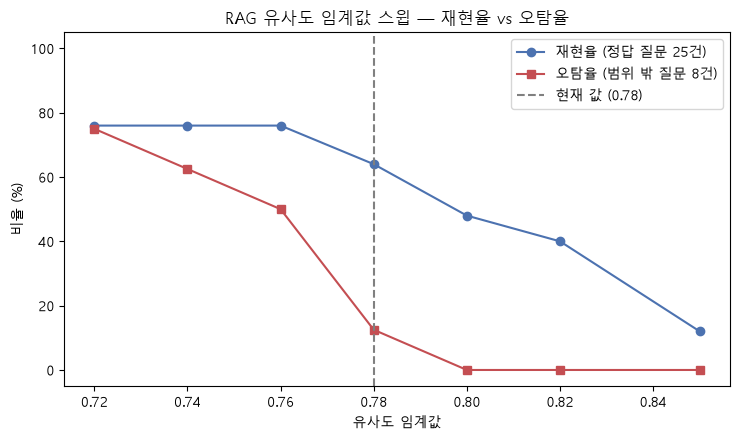

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ts = [r["threshold"] for r in sweep_rows]
recalls = [r["recall"] * 100 for r in sweep_rows]
fars = [r["false_accept_rate"] * 100 for r in sweep_rows]

ax.plot(ts, recalls, marker="o", label="재현율 (정답 질문 25건)", color="#4C72B0")
ax.plot(ts, fars, marker="s", label="오탐율 (범위 밖 질문 8건)", color="#C44E52")
ax.axvline(0.78, color="gray", linestyle="--", label="현재 값 (0.78)")
ax.set_xlabel("유사도 임계값")
ax.set_ylabel("비율 (%)")
ax.set_title("RAG 유사도 임계값 스윕 — 재현율 vs 오탐율")
ax.legend()
ax.set_ylim(-5, 105)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "01_threshold_sweep.png", dpi=150)
plt.show()

In [8]:
# 임계값별 재현율/오탐율을 MLflow run으로 기록하고, 최종 채택 결정(현재 값 0.78 유지)을 태그로 남긴다.
# 이 노트북은 새로 학습한 모델이 없다 — 사전학습 임베딩 모델(intfloat/multilingual-e5-base)을
# 검색 전용으로 그대로 쓰고, 그 검색 성능을 이 임계값으로 평가한 것이다. Model Registry에는
# "이 버전의 임계값(0.78)으로 검증된 검색 모델"이라는 의미로 그 사전학습 모델 자체를 등록한다.
CURRENT_THRESHOLD = 0.78
REGISTERED_MODEL_NAME = "rag-retrieval-embedding-model"

with mlflow.start_run(run_name="threshold-sweep"):
    mlflow.log_param("thresholds", str(thresholds))
    for row in sweep_rows:
        with mlflow.start_run(run_name=f"threshold={row['threshold']}", nested=True):
            mlflow.log_param("threshold", row["threshold"])
            mlflow.log_metric("recall", row["recall"])
            mlflow.log_metric("false_accept_rate", row["false_accept_rate"])
    mlflow.log_artifact(str(OUTPUT_DIR / "01_threshold_sweep.png"))

    current_row = next(r for r in sweep_rows if r["threshold"] == CURRENT_THRESHOLD)
    mlflow.log_param("adopted_threshold", CURRENT_THRESHOLD)
    mlflow.log_metric("adopted_recall", current_row["recall"])
    mlflow.log_metric("adopted_false_accept_rate", current_row["false_accept_rate"])
    mlflow.set_tag(
        "decision",
        "0.78 유지 — 범위 밖 질문에 그럴듯하게 오답하는 위험(오탐)이 정답 질문을 과도하게 "
        "거절하는 것(재현율 손실)보다 이 도메인에서 더 위험하다고 판단. 오탐 0%인 0.80은 "
        "재현율이 48%까지 떨어져 채택하지 않음",
    )

    mlflow.log_param("embedding_model_name", "intfloat/multilingual-e5-base")
    mlflow.log_param("embedding_dim", 768)
    mlflow.log_param("similarity_metric", "cosine")
    model_info = mlflow.sentence_transformers.log_model(
        model,
        name="e5_base_retrieval_model",
        registered_model_name=REGISTERED_MODEL_NAME,
    )

print(f"threshold-sweep MLflow 기록 완료 (Model Registry: {REGISTERED_MODEL_NAME}, model_uri={model_info.model_uri})")

🏃 View run threshold=0.72 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/9030662567a24dfe91d677637d9ce389
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.74 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/5c39cc49b5614614abe10182be52180f
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.76 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/6a8972220fdc492b8eb8057e891b6de5
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.78 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/ff6eba166dbe4d3290bcd5e3f6590c2c
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


🏃 View run threshold=0.8 at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/cd443de744794e3e8e4044ef0573ea4f
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


...

Successfully registered model 'rag-retrieval-embedding-model'.


2026/08/03 15:01:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: rag-retrieval-embedding-model, version 1


Created version '1' of model 'rag-retrieval-embedding-model'.


🏃 View run threshold-sweep at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1/runs/43893a8ef5b947039bcfa54d9882fff1
🧪 View experiment at: https://dagshub.com/saySthAbout/living-abroad.mlflow/#/experiments/1


threshold-sweep MLflow 기록 완료 (Model Registry: rag-retrieval-embedding-model, model_uri=models:/m-6b6177fc4701480ebf25ea1aeacb73c2)


In [9]:
cur.close()
conn.close()

## 결론

| 임계값 | 재현율 | 오탐율 |
|---|---|---|
| 0.72 | 76.0% | 75.0% |
| 0.74 | 76.0% | 62.5% |
| 0.76 | 76.0% | 50.0% |
| **0.78 (현재)** | **64.0%** | **12.5%** |
| 0.80 | 48.0% | 0.0% |
| 0.82 | 40.0% | 0.0% |
| 0.85 | 12.0% | 0.0% |

**현재 값 0.78은 재현율/오탐율 어느 쪽으로도 깔끔하지 않다.** 정답 질문 25건 중 이미 3건("Subclass 189 비자가 정확히 어떤
비자인가요?" 0.761, "Subclass 189 포인트는 어떻게 계산되나요?" 0.773, "배우자와 자녀를 같이 데려갈 수 있나요?" 0.779)이
올바른 문서를 1위로 찾았음에도 임계값을 못 넘어 거절당하고 있고, 동시에 범위 밖 질문 중 "학생 비자(Student visa) 신청 조건이
뭔가요?"(0.794)는 임계값을 넘어버려 Skilled Worker 영어능력증명 문서를 근거로 삼아 잘못 답변을 생성할 것이다 — 이 도메인에서는
후자(범위 밖 질문에 그럴듯하게 오답)가 전자(범위 안 질문을 과도하게 거절)보다 더 위험하다.

**단일 스칼라 임계값만으로는 깨끗하게 분리되지 않는다.** 0.80부터 오탐율이 0%가 되지만 재현율도 48%로 떨어져 절반 넘는 정답
질문을 거절하게 된다. 근본 원인은 임계값이 아니라 **검색 자체의 한계**로 보인다 — top-1 정확도 자체가 19/25(76%)에 그쳐서,
임계값을 아무리 조정해도 잘못된 문서가 1위로 검색되는 6건(예: "Express Entry 신청 시 미리 준비해야 할 서류" 질문이 "Express
Entry 준비 서류" 대신 "Category-based Selection 기준"을 1위로 반환)은 애초에 구제되지 않는다. 같은 국가 안에서 주제가
겹치는 문서들(예: GBR의 "직무·급여 요건" vs "급여 할인 기준" vs "스폰서 지침")을 임베딩 유사도만으로 구분하는 데 한계가
있다는 뜻이다.

**참고**: 이 평가는 `top_k=1`만 봤다. 실제 `ai-server/app/rag.py`는 `TOP_K=5`를 가져와 임계값을 넘는 청크를 전부 LLM에
넘기므로, 여기서 "MISS"로 잡힌 질문 중 일부는 실제 서비스에서 기대한 문서가 상위 5개 안에 포함돼 답변에 같이 인용될 수도
있다 — 이 노트북의 수치는 실제 재현율의 하한(lower bound)에 가깝다.

**권장**: 0.78을 유지할지, "범위 밖 질문에 오답하는 게 더 위험하다"는 판단으로 0.80~0.82로 올릴지는 제품 판단이 필요하다.
정량적으로는 0.80이 이 평가셋 기준 오탐 0%를 달성하는 가장 낮은 값이라 후보로 제안하지만, 재현율 손실(48%)이 크므로
`SIMILARITY_THRESHOLD` 상수를 실제로 바꾸기 전에 사람이 직접 판단하는 게 맞다 — 이 노트북은 그 판단에 필요한 근거를
만드는 것까지만 한다.